<a href="https://colab.research.google.com/github/Sayak-coder/SIH_26086/blob/main/pricipitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install tensorflow

In [5]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.3 MB/s eta 0:00:00


In [6]:
!pip install -u geemap


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u


In [7]:
import ee

In [8]:
ee.Authenticate()
ee.Initialize(
    project='gen-lang-client-0960220624',
    opt_url='https://earthengine-highvolume.googleapis.com'
)

In [9]:
import geemap

In [10]:
map=geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [11]:
roi=map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -273.658447,
                          22.024546
                        ],
                        [
                          -273.658447,
                          25.135339
                        ],
                        [
                          -271.362305,
                          25.135339
                        ],
                        [
                          -271.362305,
                          22.024546
                        ],
                        [
                          -273.658447,
                          22.024546
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [12]:
def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

coords = roi.getInfo()['coordinates']
fixed_coords = [[[wrap_lon(lon), lat] for lon, lat in ring] for ring in coords]
roi_fixed = ee.Geometry.Polygon(fixed_coords)

In [13]:
time_start=ee.Date('2015')
time_end=ee.Date('2025')
time_diff=time_end.difference(time_start,'month')

In [14]:

time_start = ee.Date('2002')
time_end  = ee.Date('2025')
time_dif = time_end.difference(time_start, 'month').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'month')
)

def monthly(date_list, col):
  start_date = ee.Date(date_list)
  end_date = start_date.advance(1, 'month')
  col_agg = col.filterDate(start_date, end_date).mean()
  return col_agg.set('system:time_start', start_date.millis())

pr = (
    ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
    .filterDate(time_start, time_end)
    .select(['precipitation'],['pr'])
)

veg = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(time_start, time_end)
    .select(['NDVI','EVI'],['ndvi','evi'])
)

temp = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(time_start, time_end)
    .select(['LST_Day_1km','LST_Night_1km'],['temp_day','temp_night'])
)

et = (
    ee.ImageCollection("MODIS/061/MOD16A2GF")
    .filterDate(time_start, time_end)
    .select(['ET'],['et'])
)

veg_monthly = ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x, veg)
    ))

temp_months= ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x,temp)
    )
)

et_monthly=ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x, et)
    )
)

pr_monthly=ee.ImageCollection(
    time_list.map(
        lambda x:monthly(x, pr)
    )
)
pr_monthly

In [15]:
landcover=(
    ee.ImageCollection("MODIS/061/MCD12Q1").filterDate(time_start,time_end).mode().select(['LC_Type1'],['lc'])
)

topography=(
    ee.Image("USGS/GTOPO30").rename('dem')
)

In [16]:
collection=veg_monthly.combine(temp_months).combine(et_monthly).combine(pr_monthly).map(
    lambda x: x.addBands(landcover).addBands(topography)
)
collection

In [17]:
import xarray as xr

In [18]:
from xee import helpers
import shapely.geometry

# roi_fixed is an ee.Geometry — convert it to GeoJSON, then to shapely
geojson_roi_fixed = roi_fixed.getInfo()
shapely_roi = shapely.geometry.shape(geojson_roi_fixed)

grid = helpers.fit_geometry(
    geometry=shapely_roi,
    grid_crs='EPSG:4326',
    grid_scale=(0.1, -0.1)
)
ds = xr.open_dataset(collection, engine='ee', **grid)

In [19]:
ds10km = ds

In [20]:
ds10km=ds10km.sortby('time')*1

In [21]:
ds10km

<xarray.Dataset> Size: 7MB
Dimensions:     (time: 276, y: 32, x: 24)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2002-01-01 2002-02-01 ... 2024-12-01
  * y           (y) float64 256B 25.15 25.05 24.95 24.85 ... 22.25 22.15 22.05
  * x           (x) float64 192B 86.35 86.45 86.55 86.65 ... 88.45 88.55 88.65
Data variables:
    ndvi        (time, y, x) float32 848kB 6.234e+03 6.364e+03 ... 4.621e+03
    evi         (time, y, x) float32 848kB 2.932e+03 3.005e+03 ... 1.846e+03
    temp_day    (time, y, x) float32 848kB 1.472e+04 1.471e+04 ... 1.476e+04
    temp_night  (time, y, x) float32 848kB 1.43e+04 1.429e+04 ... 1.461e+04
    et          (time, y, x) float32 848kB 79.75 82.0 65.75 ... 79.0 73.75 70.0
    pr          (time, y, x) float32 848kB 0.021 0.021 0.021 ... 0.011 0.01 0.01
    lc          (time, y, x) float32 848kB 12.0 4.0 12.0 12.0 ... 12.0 12.0 12.0
    dem         (time, y, x) float32 848kB 215.0 201.0 57.0 ... 3.0 11.0 7.0

In [22]:
ds10km=ds10km.to_dataframe().dropna()

In [23]:
ds10km.head()

ndvi     evi  temp_day  temp_night     et     pr  \
time       y     x                                                           
2002-01-01 25.15 86.35  6233.5  2932.0  14723.00    14300.00  79.75  0.021   
                 86.45  6364.0  3005.0  14708.25    14290.75  82.00  0.021   
                 86.55  4518.0  2598.5  14828.50    14240.00  65.75  0.021   
                 86.65  4483.5  2478.5  14851.00    14228.50  64.00  0.021   
                 86.75  4843.5  2603.0  14819.75    14224.75  69.25  0.021   

                          lc    dem  
time       y     x                   
2002-01-01 25.15 86.35  12.0  215.0  
                 86.45   4.0  201.0  
                 86.55  12.0   57.0  
                 86.65  12.0   39.0  
                 86.75  12.0   38.0

In [24]:
X10km=ds10km.drop(['pr'],axis=1)
y10km=ds10km['pr']

In [25]:
from sklearn.preprocessing import StandardScaler

X10km_scale=StandardScaler()
y10km_scale=StandardScaler()

X10km_scaled=X10km_scale.fit_transform(X10km)
y10km_scaled=y10km_scale.fit_transform(y10km.values.reshape(-1,1))

In [26]:
X10km_scaled

array([[ 1.0467995 , -0.04430667, -1.9063339 , ..., -0.53810936,
         0.01409679,  1.5498332 ],
       [ 1.1447717 ,  0.03053034, -1.9710656 , ..., -0.51170903,
        -6.910661  ,  1.3847624 ],
       [-0.24110274, -0.386199  , -1.4433378 , ..., -0.7023782 ,
         0.01409679, -0.31311038],
       ...,
       [-0.18779989, -0.41592878, -1.6232699 , ..., -0.5469095 ,
         0.01409679, -0.94981265],
       [-0.09620905, -0.49999225, -1.6858073 , ..., -0.6085103 ,
         0.01409679, -0.85548633],
       [-0.16377605, -1.1581478 , -1.735179  , ..., -0.6525109 ,
         0.01409679, -0.9026495 ]], dtype=float32)

In [27]:
y10km_scaled

array([[-0.74470943],
       [-0.74470943],
       [-0.74470943],
       ...,
       [-0.804846  ],
       [-0.8108597 ],
       [-0.8108597 ]], dtype=float32)

In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X10km_scaled,y10km_scaled,test_size=0.2,random_state=42)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [30]:
model=Sequential()
model.add(Dense(64,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [31]:
from re import VERBOSE
model.fit(
    X_train,y_train,epochs=10,batch_size=8,validation_split=0.2,verbose=1
)

Epoch 1/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.2491 - mae: 0.3316 - val_loss: 0.2377 - val_mae: 0.3345
Epoch 2/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.2267 - mae: 0.3123 - val_loss: 0.2229 - val_mae: 0.3055
Epoch 3/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.2184 - mae: 0.3050 - val_loss: 0.2129 - val_mae: 0.3041
Epoch 4/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.2140 - mae: 0.3008 - val_loss: 0.2120 - val_mae: 0.3061
Epoch 5/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.2114 - mae: 0.2989 - val_loss: 0.2203 - val_mae: 0.3001
Epoch 6/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.2094 - mae: 0.2971 - val_loss: 0.2087 - val_mae: 0.2930
Epoch 7/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.2078 - mae: 0.2956 - val_loss: 0.2070 - val_mae: 0.2915
Epoch 8/10
15710/15710 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 0.2059 - mae: 0.2946 - val_loss: 0.2080 - val_mae: 0.2938
Epoch 9/10
15710

In [32]:
model_evaluation=model.evaluate(X_test,y_test)

1228/1228 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.2099 - mae: 0.2927


In [33]:
geojson_roi_fixed = roi_fixed.getInfo()
shapely_roi = shapely.geometry.shape(geojson_roi_fixed)

grid = helpers.fit_geometry(
    geometry=shapely_roi,
    grid_crs='EPSG:4326',
    grid_scale=(0.01, -0.01)
)
ds1km = xr.open_dataset(collection, engine='ee', **grid)

In [34]:
ds1km

<xarray.Dataset> Size: 634MB
Dimensions:     (time: 276, y: 312, x: 230)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2002-01-01 2002-02-01 ... 2010-04-01
  * y           (y) float64 2kB 25.14 25.12 25.12 25.11 ... 22.05 22.04 22.03
  * x           (x) float64 2kB 86.34 86.36 86.36 86.38 ... 88.61 88.62 88.64
Data variables:
    ndvi        (time, y, x) float32 79MB ...
    evi         (time, y, x) float32 79MB ...
    temp_day    (time, y, x) float32 79MB ...
    temp_night  (time, y, x) float32 79MB ...
    et          (time, y, x) float32 79MB ...
    pr          (time, y, x) float32 79MB ...
    lc          (time, y, x) float32 79MB ...
    dem         (time, y, x) float32 79MB ...

In [35]:
ds1km=ds1km.to_dataframe().dropna()

In [36]:
ds1km

ndvi     evi      temp_day    temp_night  \
time       y      x                                                    
2002-01-01 25.135 86.345  6866.5  3197.0  14690.500000  14271.500000   
                  86.355  7283.0  3315.0  14674.750000  14277.250000   
                  86.365  7477.5  3423.5  14666.250000  14285.000000   
                  86.375  7454.5  3349.0  14671.750000  14288.000000   
                  86.385  7041.0  2982.0  14685.750000  14291.000000   
...                          ...     ...           ...           ...   
2010-04-01 22.025 88.585  3354.5  2016.0  15320.333008  14905.666992   
                  88.595  2177.0  1188.0  15303.666992  14909.000000   
                  88.605  1808.0   984.0  15283.000000  14913.000000   
                  88.615  1784.0  1033.0  15219.500000  14915.666992   
                  88.625   456.0   346.5  15191.000000  14954.666992   

                                 et     pr    lc    dem  
time       y      x                                      
2002-01-01 25.135 86.345  95.250000  0.021   4.0  188.0  
                  86.355  83.250000  0.021   4.0  213.0  
                  86.365  91.250000  0.021   4.0  246.0  
                  86.375  86.500000  0.021   4.0  294.0  
                  86.385  79.250000  0.021   4.0  321.0  
...                             ...    ...   ...    ...  
2010-04-01 22.025 88.585  68.666664  0.012  12.0   12.0  
                  88.595  55.666668  0.012  12.0   13.0  
                  88.605  54.333332  0.011  12.0   10.0  
                  88.615  54.666668  0.011  12.0   11.0  
                  88.625  54.000000  0.011  11.0    1.0  

[16973558 rows x 8 columns]

In [37]:
X1km=ds1km.drop(['pr'],axis=1)
y1km=ds1km['pr']

In [38]:
X1km_scale=StandardScaler()
y1km_scale=StandardScaler()

X1km_scaled=X1km_scale.fit_transform(X1km)
y1km_scaled=y1km_scale.fit_transform(y1km.values.reshape(-1,1))

In [39]:
X1km_scaled

array([[ 1.3388262 ,  0.19346423, -2.0150084 , ..., -0.27285632,
        -6.4355435 ,  1.2289004 ],
       [ 1.6185489 ,  0.30242237, -2.0818338 , ..., -0.4157201 ,
        -6.4355435 ,  1.5233086 ],
       [ 1.7491758 ,  0.40260845, -2.1178985 , ..., -0.32047758,
        -6.4355435 ,  1.9119275 ],
       ...,
       [-2.0584788 , -1.8499626 ,  0.49889824, ..., -0.75998217,
         0.08585619, -0.86728597],
       [-2.0745974 , -1.8047173 ,  0.22947532, ..., -0.7560137 ,
         0.08585619, -0.85550964],
       [-2.9664862 , -2.4386137 ,  0.10855322, ..., -0.7639506 ,
        -0.7293188 , -0.9732729 ]], dtype=float32)

In [40]:
y1km_scaled

array([[-0.6991273 ],
       [-0.6991273 ],
       [-0.6991273 ],
       ...,
       [-0.76380134],
       [-0.76380134],
       [-0.76380134]], dtype=float32)

In [43]:
print('hi')

hi


In [44]:
ds1km['pr1km']=y1km_scale.inverse_transform(model.predict(X1km_scaled))

530424/530424 ━━━━━━━━━━━━━━━━━━━━ 603s 1ms/step


In [45]:
ds1km

ndvi     evi      temp_day    temp_night  \
time       y      x                                                    
2002-01-01 25.135 86.345  6866.5  3197.0  14690.500000  14271.500000   
                  86.355  7283.0  3315.0  14674.750000  14277.250000   
                  86.365  7477.5  3423.5  14666.250000  14285.000000   
                  86.375  7454.5  3349.0  14671.750000  14288.000000   
                  86.385  7041.0  2982.0  14685.750000  14291.000000   
...                          ...     ...           ...           ...   
2010-04-01 22.025 88.585  3354.5  2016.0  15320.333008  14905.666992   
                  88.595  2177.0  1188.0  15303.666992  14909.000000   
                  88.605  1808.0   984.0  15283.000000  14913.000000   
                  88.615  1784.0  1033.0  15219.500000  14915.666992   
                  88.625   456.0   346.5  15191.000000  14954.666992   

                                 et     pr    lc    dem     pr1km  
time       y      x                                                
2002-01-01 25.135 86.345  95.250000  0.021   4.0  188.0 -0.007409  
                  86.355  83.250000  0.021   4.0  213.0 -0.009202  
                  86.365  91.250000  0.021   4.0  246.0 -0.005839  
                  86.375  86.500000  0.021   4.0  294.0 -0.005343  
                  86.385  79.250000  0.021   4.0  321.0 -0.005973  
...                             ...    ...   ...    ...       ...  
2010-04-01 22.025 88.585  68.666664  0.012  12.0   12.0  0.166678  
                  88.595  55.666668  0.012  12.0   13.0  0.113406  
                  88.605  54.333332  0.011  12.0   10.0  0.098991  
                  88.615  54.666668  0.011  12.0   11.0  0.122925  
                  88.625  54.000000  0.011  11.0    1.0  0.082348  

[16973558 rows x 9 columns]

In [46]:
result=ds1km[['pr','pr1km']].to_xarray().sortby(['time','x','y'])

In [48]:
result_sub=result.sel(time='2024')

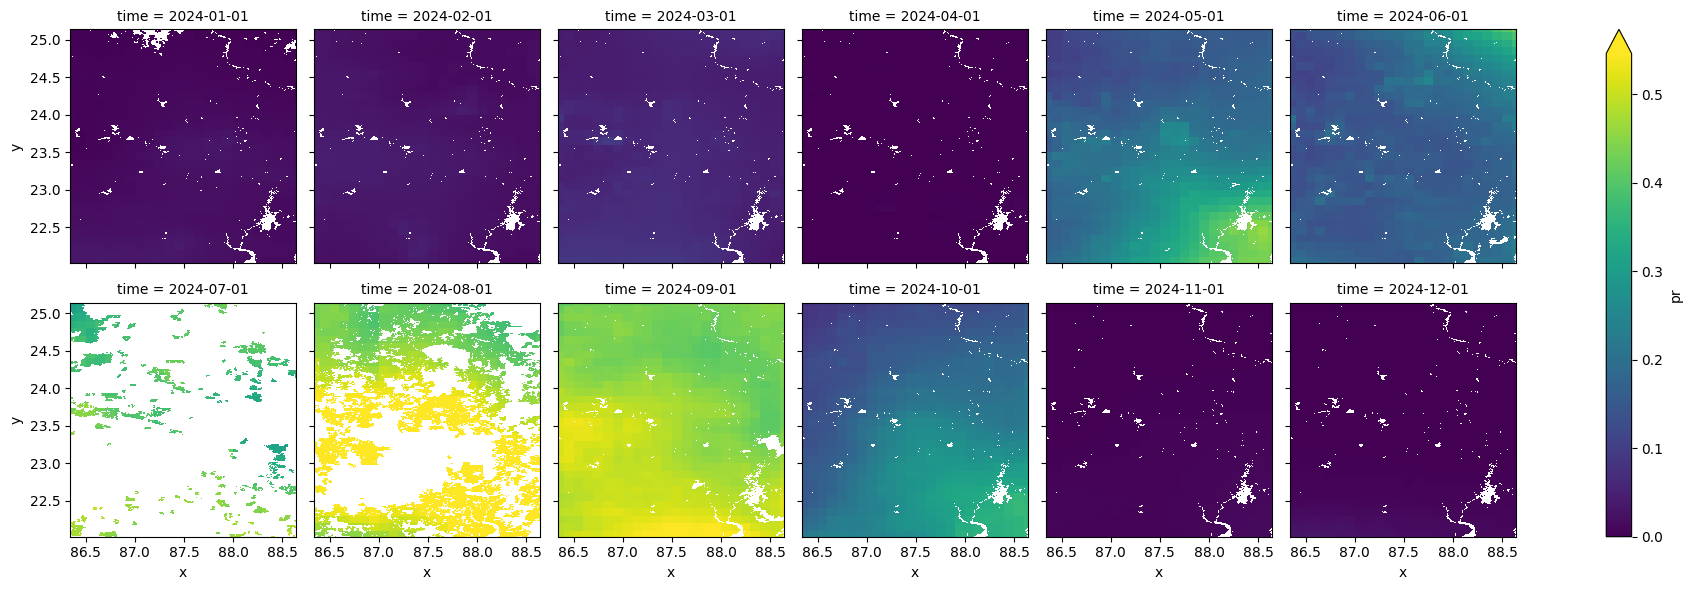

In [50]:
result_sub.pr.plot(
    x='x',y='y',col='time',robust = True, col_wrap = 6
)

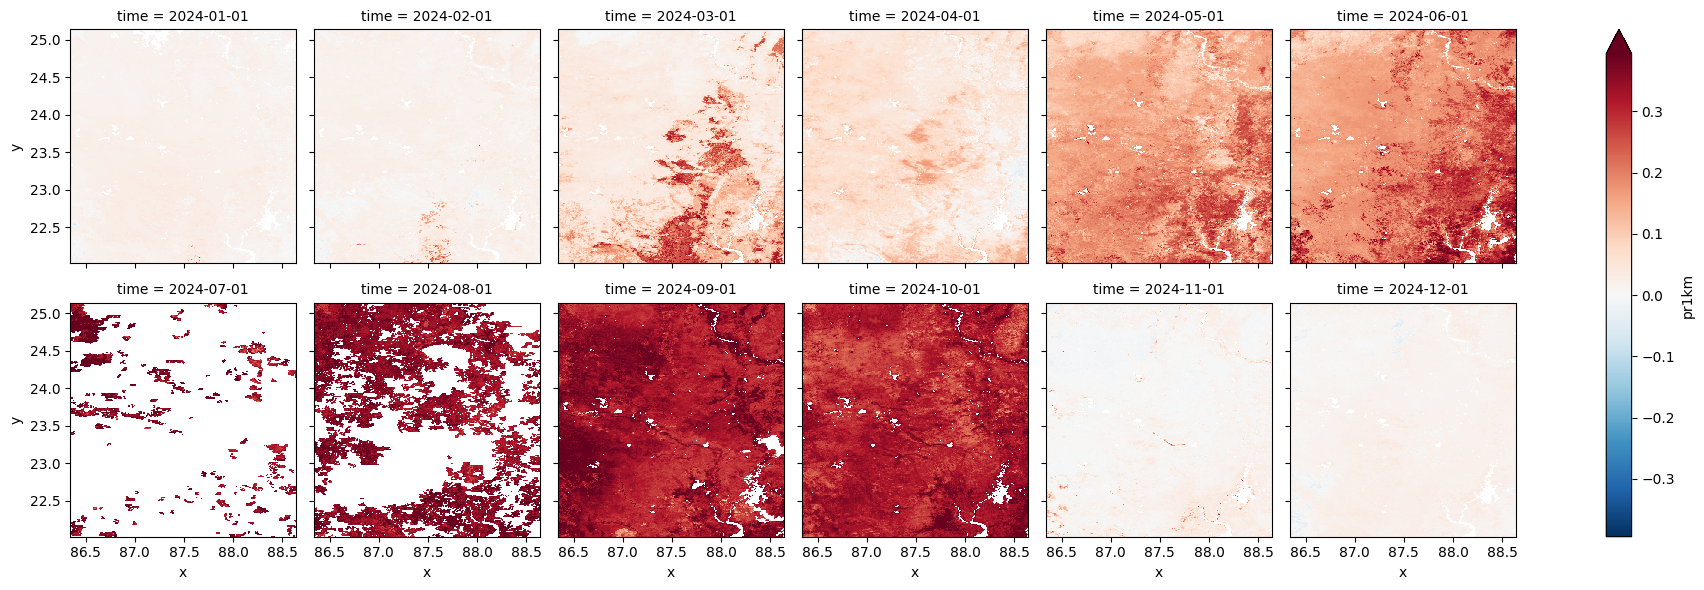

In [51]:
result_sub.pr1km.plot(
    x='x',y='y',col='time',robust = True, col_wrap = 6
)